## Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import re
import matplotlib.image as mpimg
import os
from PIL import Image
from itertools import product

from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

from functools import partial

# Полностью отключить все предупреждения
warnings.filterwarnings("ignore")

os.makedirs("ims", exist_ok=True)
# os.makedirs("ims/current", exist_ok=True)
os.makedirs("ims/all", exist_ok=True)

plt.rcParams['font.family'] = 'serif'
import matplotlib
# matplotlib.use('Agg')
# print(matplotlib.get_backend())

## extract

In [2]:
def extract_first_symbol(s):
    return int(s[0])

def extract_c_num(s):
    start = s.index('c') + 1
    end = s.index('_', start)
    return int(s[start:end])

def extract_s_num(s):
    start = s.index('_s') + 2
    end = s.index('_', start)
    return float(s[start:end])

def extract_k_num(s):
    start = s.index('_k') + 2
    end = s.index('_', start)
    return int(s[start:end])

def extract_a_num(s):
    start = s.index('_a') + 2
    end = s.index('_', start)
    return float(s[start:end])

def extract_r_num(s):
    start = s.index('_r') + 2
    end = s.index('_', start)
    return float(s[start:end])

def extract_i_num(s):
    start = s.index('_i') + 2
    end = s.index('_', start)
    return float(s[start:end])

def extract_p(s):
    match = re.search(r'p([^_]+)', s)
    s1 = match.group(1).split('d')[0]
    s2 = match.group(1).split('d')[1]
    return float(s2+s1)
        # return match.group(1)[-2:]+match.group(1)[:-2]

In [3]:
ax = 'z'

folders = [name for name in os.listdir('.') if os.path.isdir(os.path.join('.', name))]

# folders = [f for f in folders if f.startswith('c')]
folders = [f for f in folders 
           if f[0].isdigit() 
           and os.path.isfile(os.path.join(f, 'probe_pulse_rt.data')) 
           and not os.path.isdir(os.path.join(f, 'restart'))]


# print(folders)


# Сортировка: сначала по c, потом по s, потом по k
# sorted_folders = sorted(folders, key=lambda s: (extract_p(s), extract_c_num(s), extract_r_num(s), extract_s_num(s), extract_k_num(s), extract_a_num(s), extract_i_num(s)))

sorted_folders = sorted(folders, key=lambda s: extract_first_symbol(s))

In [4]:
sorted_folders

['1_c333_s0.00_r18_k16_a1_i800_t9_p3d10_5d11_load_№856_amorphous_0.992',
 '2_c333_s0.00_r18_k16_a1_i800_t9_p3d10_5d11_load_№1162_amorphous_0.976',
 '3_c333_s0.00_r18_k16_a1_i800_t9_p3d10_5d11_load_№941_amorphous_0.961',
 '4_c333_s0.00_r18_k16_a1_i800_t9_p3d10_5d11_load_№1142_amorphous_0.950',
 '5_c333_s0.00_r18_k16_a1_i800_t9_p3d10_5d11_load_№854_amorphous_0.940',
 '6_c333_s0.00_r18_k16_a1_i800_t9_p3d10_5d11_load_№889_amorphous_0.930',
 '7_c333_s0.00_r18_k16_a1_i800_t9_p3d10_5d11_load_№852_amorphous_0.920']

## histograms

In [8]:
folder = sorted_folders[0]

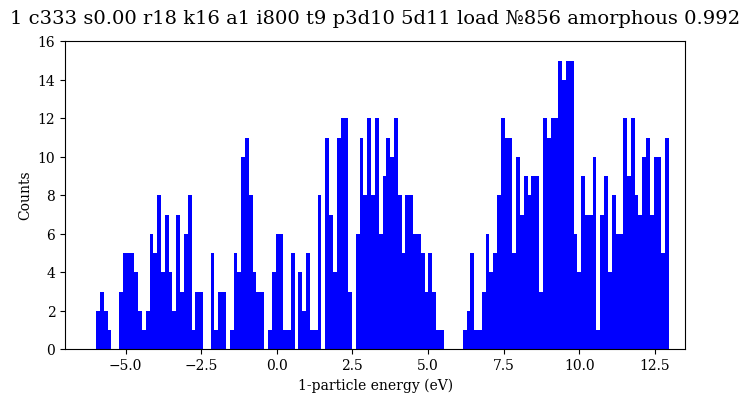

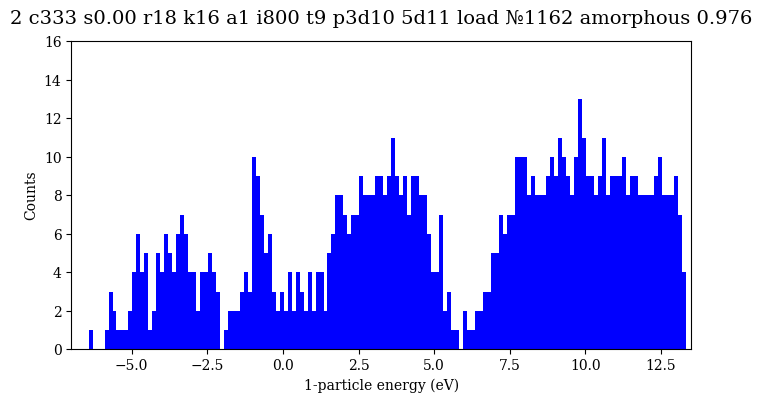

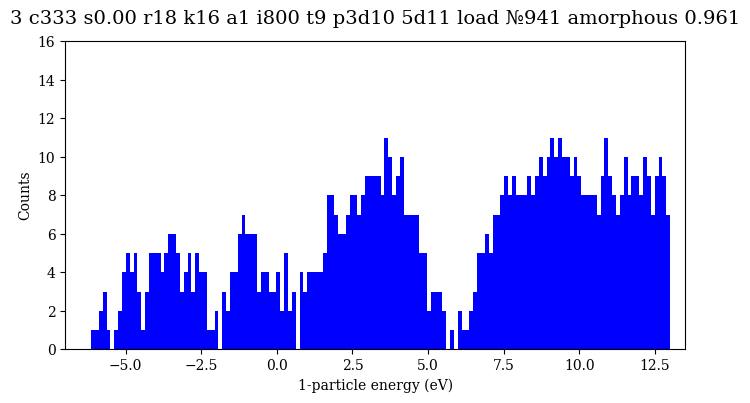

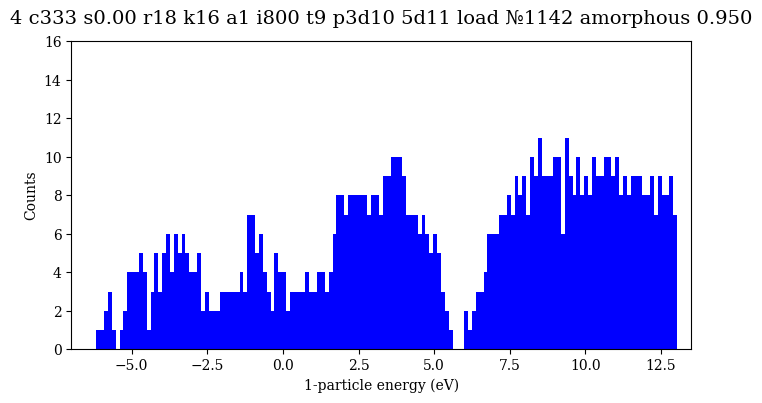

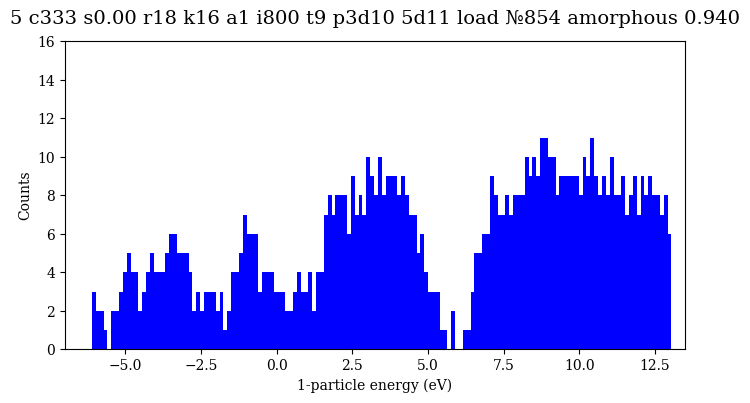

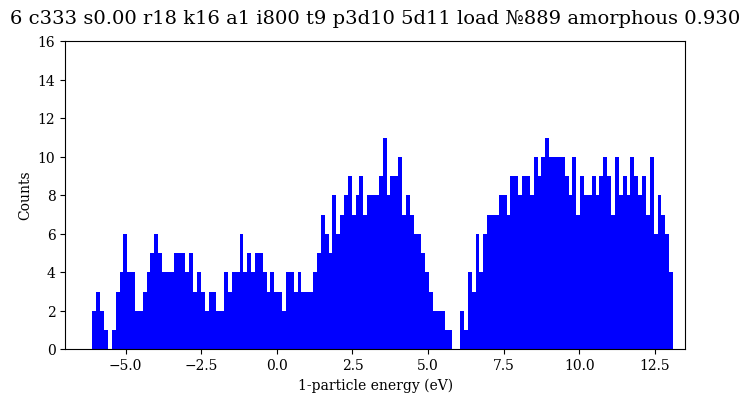

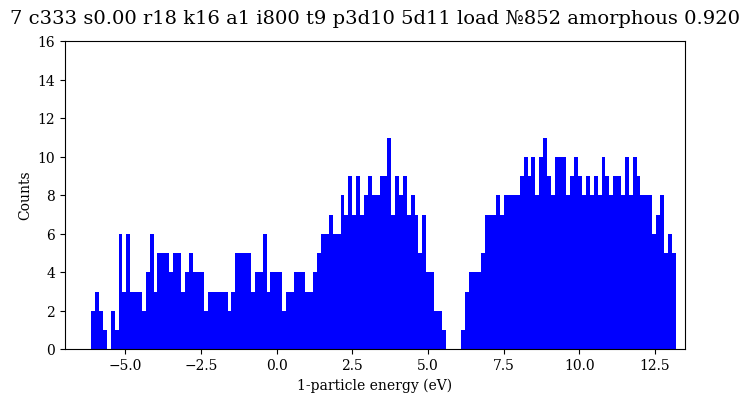

In [109]:
for num_folder in range(7):

    folder = sorted_folders[num_folder]
    
    path = folder + "/gs_info.data"   # или полный путь: "/mnt/data/gs_info.data"
    
    # --- читаем файл ---
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read()
    
    # --- достаём ожидаемое число состояний (864) ---
    m = re.search(r"Number of states\s*=\s*(\d+)", text)
    n_states = int(m.group(1)) if m else 864
    
    # --- находим блок "1-particle energies (eV)" и парсим пары (index, energy) ---
    pos = text.find("1-particle energies")
    if pos == -1:
        raise RuntimeError("Не нашёл в файле строку '1-particle energies'.")
    
    block = text[pos:]  # всё начиная с этого места
    
    # пары вида: <целый индекс> <вещественное число>
    pairs = re.findall(r"\b(\d+)\s+([-+]?\d+(?:\.\d*)?(?:[eE][-+]?\d+)?)", block)
    
    energies = np.empty(n_states, dtype=float)
    
    count = 0
    for i_str, e_str in pairs:
        i = int(i_str)
        e = float(e_str)
        if 1 <= i <= n_states:
            energies[i - 1] = e
            count += 1
            if count == n_states:
                break
    
    if count != n_states:
        raise RuntimeError(f"Извлеклось {count} энергий, ожидалось {n_states}. Проверь формат файла/блок.")
    
    # --- гистограмма ---
    plt.figure(figsize=(8, 4))
    plt.title(' '.join(re.split('[/_]', folder)), fontsize=14, y=1.03)
    plt.hist(energies, bins=150, color='b')  # bins можешь менять
    plt.xlabel("1-particle energy (eV)")
    plt.ylabel("Counts")
    plt.ylim(0, 16)
    plt.xlim(-7, 13.5)
    # plt.tight_layout()
    # plt.savefig("dos/" + folder + ".png", dpi=200)


In [134]:
folder = sorted_folders[0]
path = folder + "/gs_info.data"   # или полный путь: "/mnt/data/gs_info.data"
# --- читаем файл ---
with open(path, "r", encoding="utf-8", errors="ignore") as f:
    text = f.read()
# --- достаём ожидаемое число состояний (864) ---
m = re.search(r"Number of states\s*=\s*(\d+)", text)
n_states = int(m.group(1)) if m else 864
# --- находим блок "1-particle energies (eV)" и парсим пары (index, energy) ---
pos = text.find("1-particle energies")
if pos == -1:
    raise RuntimeError("Не нашёл в файле строку '1-particle energies'.")
block = text[pos:]  # всё начиная с этого места
# пары вида: <целый индекс> <вещественное число>
pairs = re.findall(r"\b(\d+)\s+([-+]?\d+(?:\.\d*)?(?:[eE][-+]?\d+)?)", block)

energies_1 = np.empty(n_states, dtype=float)


count = 0
for i_str, e_str in pairs:
    i = int(i_str)
    e = float(e_str)
    if 1 <= i <= n_states:
        energies_1[i - 1] = e
        count += 1
        if count == n_states:
            break

if count != n_states:
    raise RuntimeError(f"Извлеклось {count} энергий, ожидалось {n_states}. Проверь формат файла/блок.")




folder = sorted_folders[2]
path = folder + "/gs_info.data"   # или полный путь: "/mnt/data/gs_info.data"
# --- читаем файл ---
with open(path, "r", encoding="utf-8", errors="ignore") as f:
    text = f.read()
# --- достаём ожидаемое число состояний (864) ---
m = re.search(r"Number of states\s*=\s*(\d+)", text)
n_states = int(m.group(1)) if m else 864
# --- находим блок "1-particle energies (eV)" и парсим пары (index, energy) ---
pos = text.find("1-particle energies")
if pos == -1:
    raise RuntimeError("Не нашёл в файле строку '1-particle energies'.")
block = text[pos:]  # всё начиная с этого места
# пары вида: <целый индекс> <вещественное число>
pairs = re.findall(r"\b(\d+)\s+([-+]?\d+(?:\.\d*)?(?:[eE][-+]?\d+)?)", block)

energies_2 = np.empty(n_states, dtype=float)


count = 0
for i_str, e_str in pairs:
    i = int(i_str)
    e = float(e_str)
    if 1 <= i <= n_states:
        energies_2[i - 1] = e
        count += 1
        if count == n_states:
            break

if count != n_states:
    raise RuntimeError(f"Извлеклось {count} энергий, ожидалось {n_states}. Проверь формат файла/блок.")

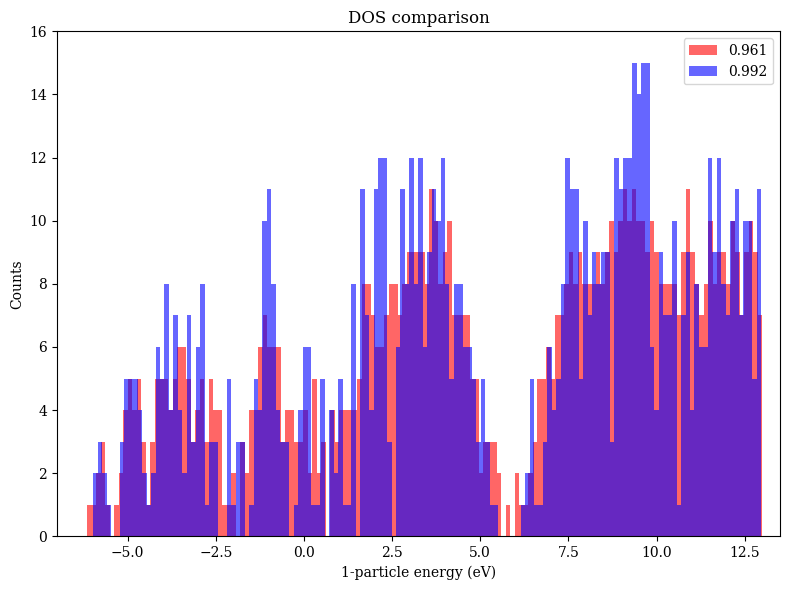

In [140]:
plt.figure(figsize=(8, 6))
plt.title("DOS comparison")
plt.hist(energies_2, bins=150, color='r', alpha=0.6, label="0.961")
plt.hist(energies_1, bins=150, color='b', alpha=0.6, label="0.992")
plt.xlabel("1-particle energy (eV)")
plt.ylabel("Counts")
plt.ylim(0, 16)
plt.xlim(-7, 13.5)
plt.tight_layout()
plt.legend()
# plt.savefig("DOS_comparison" + ".png", dpi=200)
plt.show()

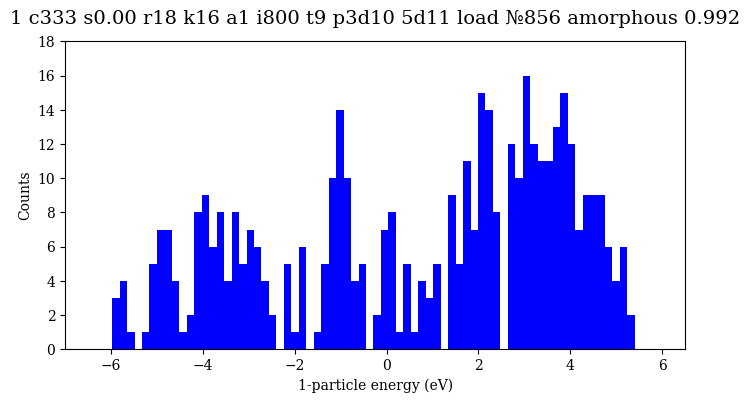

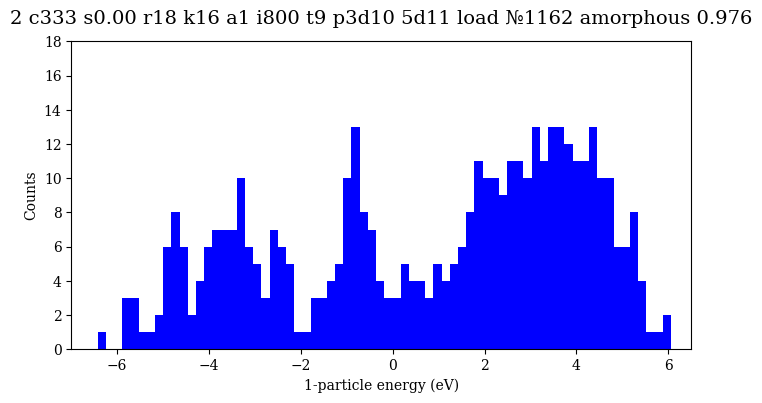

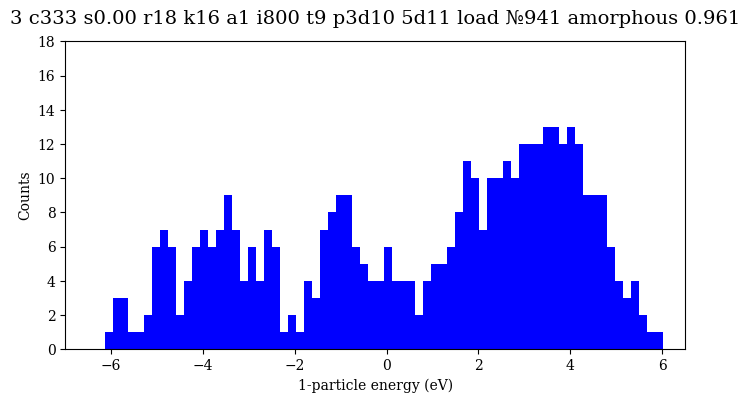

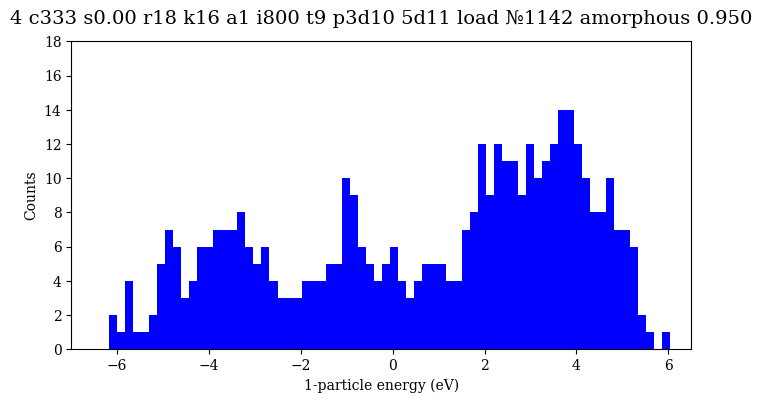

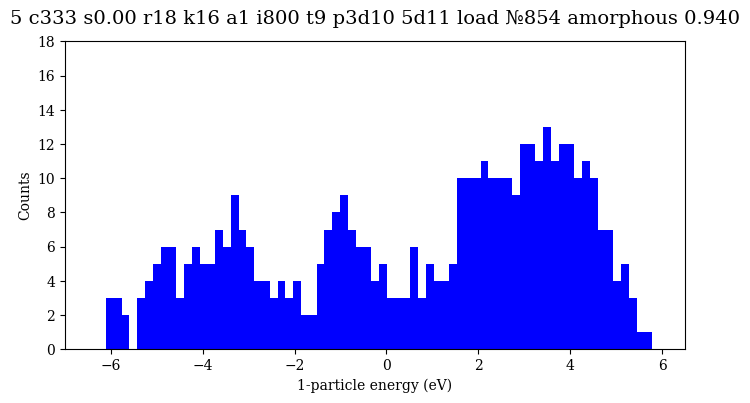

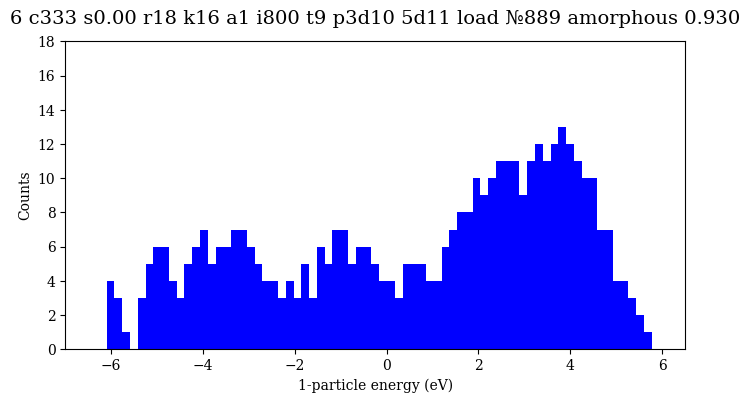

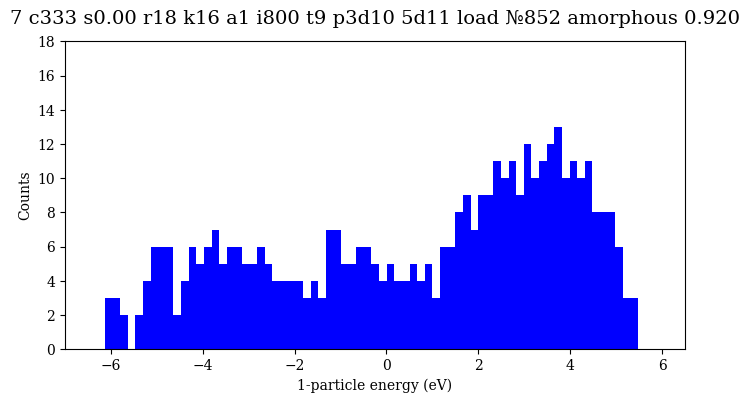

In [114]:
for num_folder in range(7):

    folder = sorted_folders[num_folder]
    
    path = folder + "/gs_info.data"   # или полный путь: "/mnt/data/gs_info.data"
    
    # --- читаем файл ---
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read()
    
    # --- достаём ожидаемое число состояний (864) ---
    m = re.search(r"Number of states\s*=\s*(\d+)", text)
    n_states = int(m.group(1)) if m else 864
    
    # --- находим блок "1-particle energies (eV)" и парсим пары (index, energy) ---
    pos = text.find("1-particle energies")
    if pos == -1:
        raise RuntimeError("Не нашёл в файле строку '1-particle energies'.")
    
    block = text[pos:]  # всё начиная с этого места
    
    # пары вида: <целый индекс> <вещественное число>
    pairs = re.findall(r"\b(\d+)\s+([-+]?\d+(?:\.\d*)?(?:[eE][-+]?\d+)?)", block)
    
    energies = np.empty(n_states, dtype=float)
    
    count = 0
    for i_str, e_str in pairs:
        i = int(i_str)
        e = float(e_str)
        if 1 <= i <= n_states:
            energies[i - 1] = e
            count += 1
            if count == n_states:
                break
    
    if count != n_states:
        raise RuntimeError(f"Извлеклось {count} энергий, ожидалось {n_states}. Проверь формат файла/блок.")
    
    # --- гистограмма ---
    plt.figure(figsize=(8, 4))
    plt.title(' '.join(re.split('[/_]', folder)), fontsize=14, y=1.03)
    plt.hist(energies[:432], bins=70, color='b')  # bins можешь менять
    plt.xlabel("1-particle energy (eV)")
    plt.ylabel("Counts")
    plt.ylim(0, 18)
    plt.xlim(-7, 6.5)
    # plt.tight_layout()
    # plt.savefig("dos/valence/" + folder + ".png", dpi=200)


## dos from salmon example

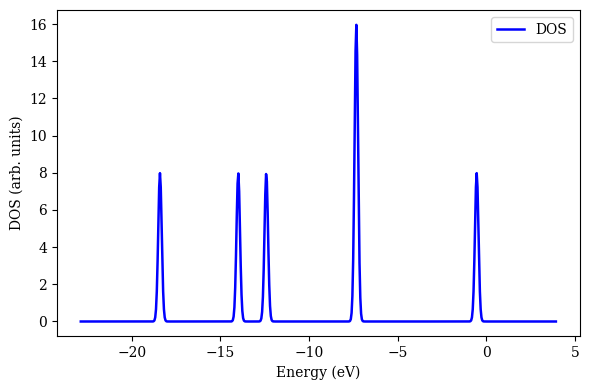

In [5]:
path = "dos.data"   # или "dos.data" если файл рядом

# --- читаем dos.data (пропускаем пустые строки и комментарии) ---
data = []
with open(path, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        s = line.strip()
        if not s or s.startswith("#") or s.startswith("!"):
            continue
        parts = s.split()
        try:
            row = [float(x) for x in parts]
        except ValueError:
            continue
        data.append(row)

arr = np.array(data, dtype=float)

if arr.ndim != 2 or arr.shape[1] < 2:
    raise RuntimeError("Файл dos.data должен содержать минимум 2 колонки: Energy  DOS")

E = arr[:, 0]          # энергия (обычно eV)
dos_cols = arr[:, 1:]  # одна или несколько колонок DOS/PDOS

# --- график DOS ---
plt.figure(figsize=(6, 4))

if dos_cols.shape[1] == 1:
    plt.plot(E, dos_cols[:, 0], lw=1.8, label="DOS", color='b')
else:
    # если колонок несколько — рисуем все (например, total + PDOS)
    for j in range(dos_cols.shape[1]):
        plt.plot(E, dos_cols[:, j], lw=1.6, label=f"DOS {j+1}", color='b')

plt.xlabel("Energy (eV)")
plt.ylabel("DOS (arb. units)")
plt.legend()
plt.tight_layout()
plt.show()


## full dos hist

In [6]:
def read_energies_for_k(filename, k_target, n_levels=864):
    """
    Возвращает массив энергий (eV) длины n_levels для заданного k
    """
    energies = []
    reading = False

    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()

            # начало блока
            if line.startswith('k='):
                k_current = int(line.split(',')[0].split('=')[1])
                reading = (k_current == k_target)
                continue

            # читаем строки с энергиями
            if reading:
                if len(energies) < n_levels:
                    parts = line.split()
                    energy = float(parts[1])  # столбец esp[eV]
                    energies.append(energy)
                else:
                    break

    if len(energies) != n_levels:
        raise ValueError(f'Для k={k_target} найдено {len(energies)} уровней, ожидалось {n_levels}')

    return np.array(energies)

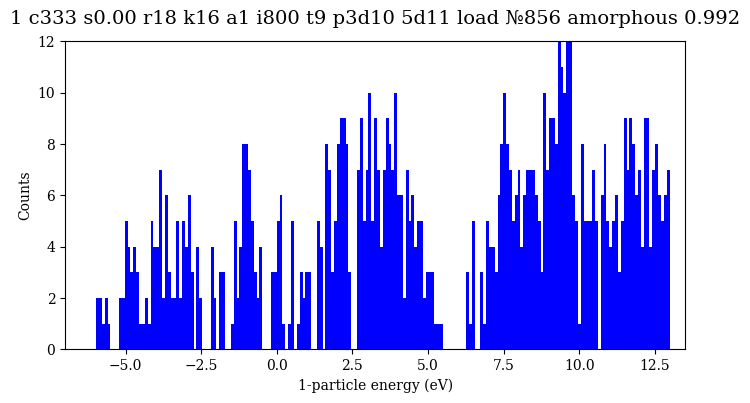

In [80]:
folder = sorted_folders[0]
filename = folder + '/gs_eigen.data'

bins_num = 200


for k_val in range(125):

    energies = read_energies_for_k(filename, k_val+1)


    if (k_val+1)==125:
    
        plt.figure(figsize=(8, 4))
        plt.title(' '.join(re.split('[/_]', folder)), fontsize=14, y=1.03)
        plt.hist(energies, bins=bins_num, color='b')  # bins можешь менять
        plt.xlabel("1-particle energy (eV)")
        plt.ylabel("Counts")
        plt.ylim(0, 12)
        plt.xlim(-7, 13.5)

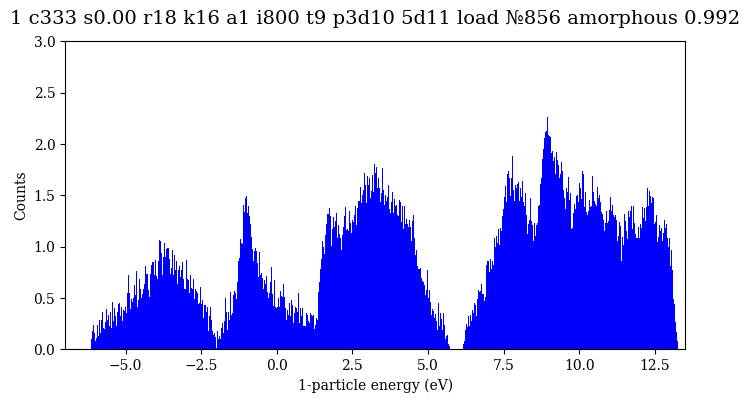

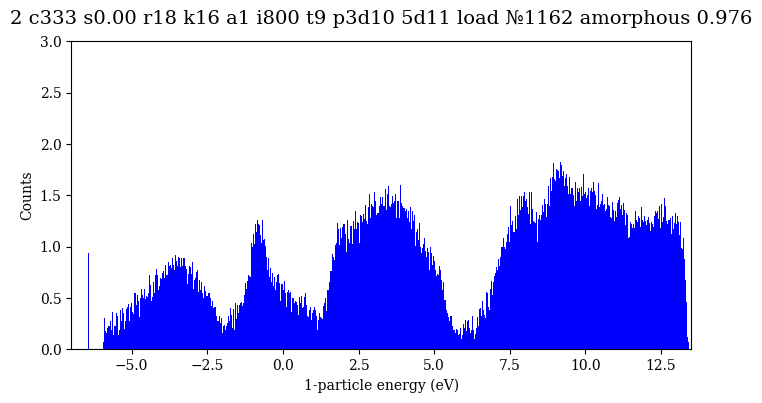

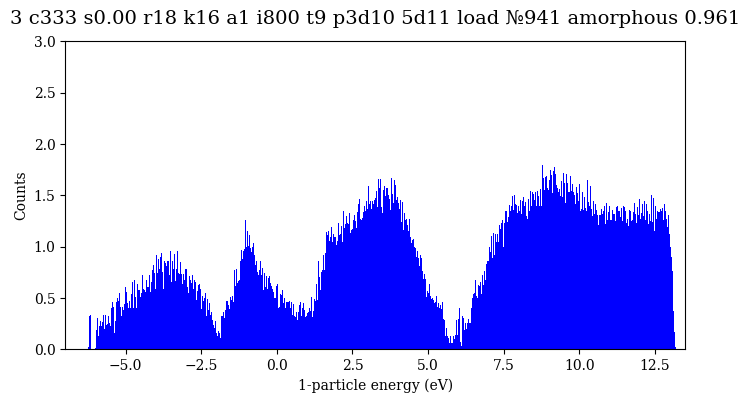

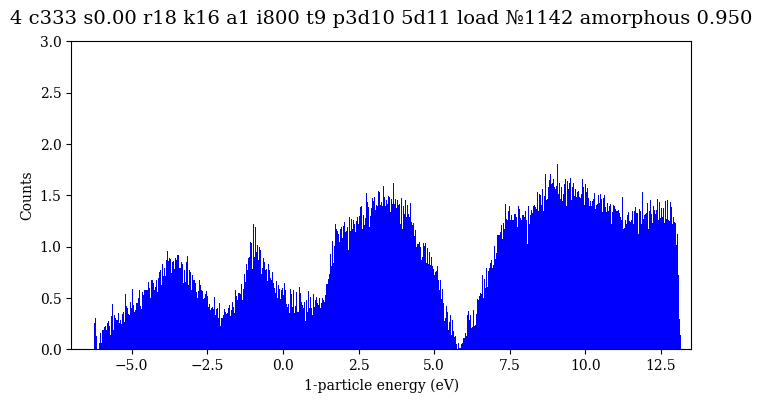

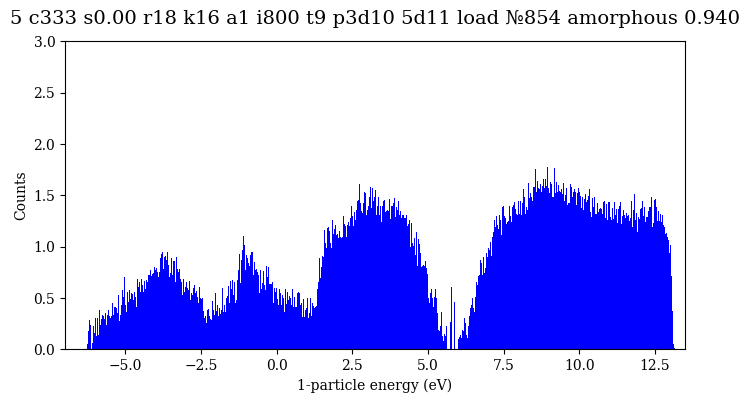

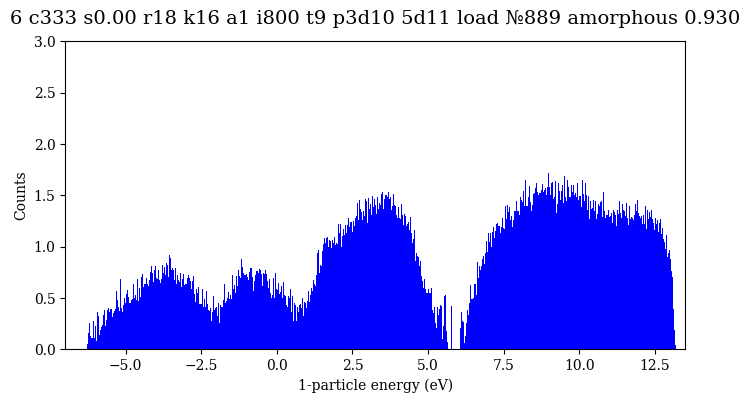

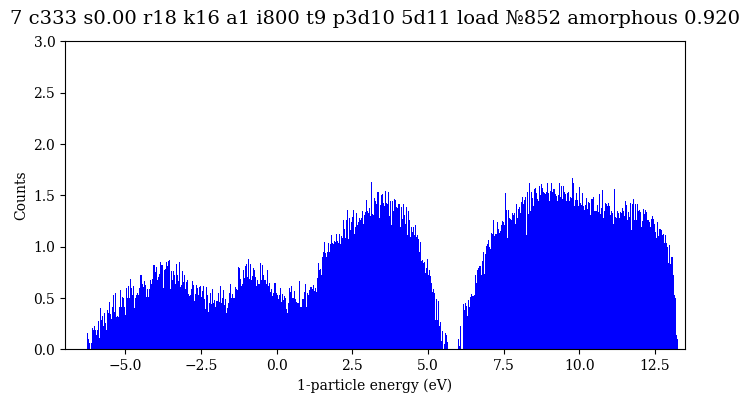

In [86]:

for folder_name in sorted_folders:

    
    filename = folder_name + '/gs_eigen.data'
    
    n_bins = 1000
    bins_vals = np.linspace(-7, 13.5, n_bins)
    hist_sum = np.zeros(n_bins-1)
    
    
    
    for k_val in range(125):
    
        energies = read_energies_for_k(filename, k_val+1)
        hist, _ = np.histogram(energies, bins=bins_vals)
        hist_sum = hist_sum + hist
    
        # if (k_val+1)%25==0:
        if (k_val+1)==125:
    
            plt.figure(figsize=(8, 4))
            plt.title(' '.join(re.split('[/_]', folder_name)), fontsize=14, y=1.03)
            plt.bar(bins_vals[:-1], hist_sum/(k_val+1), width=np.diff(bins_vals), align='edge', color='b')
            plt.xlabel("1-particle energy (eV)")
            plt.ylabel("Counts")
            plt.ylim(0, 15*200/n_bins)
            plt.xlim(-7, 13.5)
            plt.show()

## full dos plot

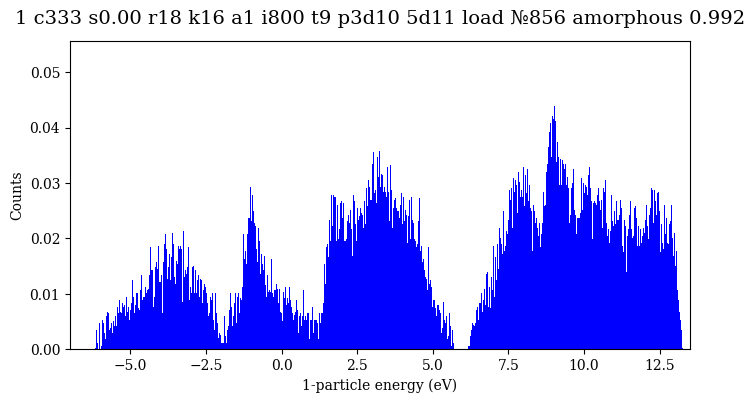

Number of states : 32.0


In [187]:
folder_name = sorted_folders[0]
filename = folder_name + '/gs_eigen.data'

n_bins = 2000
bins_vals = np.linspace(-7, 13.5, n_bins)
hist_sum = np.zeros(n_bins-1)



for k_val in range(125):

    energies = read_energies_for_k(filename, k_val+1)
    hist, _ = np.histogram(energies, bins=bins_vals)
    hist_sum = hist_sum + hist

    # if (k_val+1)%25==0:
    if (k_val+1)==125:

        plt.figure(figsize=(8, 4))
        plt.title(' '.join(re.split('[/_]', folder_name)), fontsize=14, y=1.03)
        plt.bar(bins_vals[:-1], hist_sum/(k_val+1)/27, width=np.diff(bins_vals), align='edge', color='b')
        plt.xlabel("1-particle energy (eV)")
        plt.ylabel("Counts")
        plt.ylim(0, 15*200/n_bins/27)
        plt.xlim(-7, 13.5)
        plt.show()

hist_sum_cell = hist_sum/125/27
print("Number of states :", np.sum(hist_sum_cell))

bins_centers = (bins_vals[:-1]+bins_vals[1:])/2

In [188]:
# def delta_gauss(x, sigma, x0):
#     return np.exp(-(x-x0)**2 / (2*sigma**2)) / (np.sqrt(2*np.pi)*sigma)


# x = np.linspace(-7, 13.5, 2000)
# delta = delta_gauss(x, 0.05, 0.5)

# # проверка нормировки
# print(np.trapz(delta, x))

# plt.plot(x, delta, color='b')
# plt.grid()

Text(0, 0.5, 'DOS/states/eV')

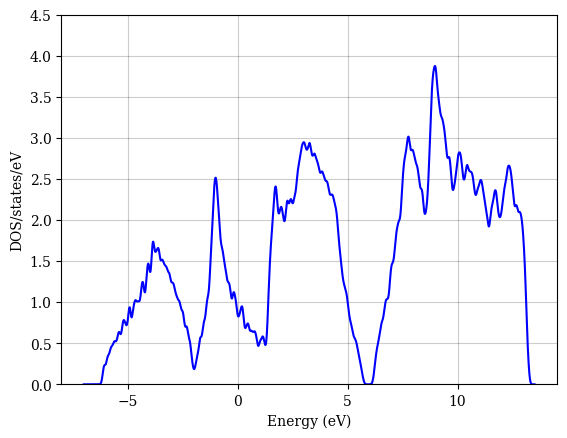

In [212]:
num_points = 30000
energy_vals = np.linspace(-7, 13.5, num_points)
del_width = (bins_centers[1]-bins_centers[0])

delta_sum = np.zeros(num_points)

for bin_center, hist_val in zip(bins_centers, hist_sum_cell):
    delta = delta_gauss(energy_vals, del_width/0.2, bin_center)

    delta_sum = delta_sum + hist_val*delta


plt.plot(energy_vals, delta_sum, color='b')
plt.ylim(0, 4.5)
plt.grid(color='black', alpha=0.2)
plt.xlabel("Energy (eV)")
plt.ylabel("DOS/states/eV")

In [216]:
sorted_folders

['1_c333_s0.00_r18_k16_a1_i800_t9_p3d10_5d11_load_№856_amorphous_0.992',
 '2_c333_s0.00_r18_k16_a1_i800_t9_p3d10_5d11_load_№1162_amorphous_0.976',
 '3_c333_s0.00_r18_k16_a1_i800_t9_p3d10_5d11_load_№941_amorphous_0.961',
 '4_c333_s0.00_r18_k16_a1_i800_t9_p3d10_5d11_load_№1142_amorphous_0.950',
 '5_c333_s0.00_r18_k16_a1_i800_t9_p3d10_5d11_load_№854_amorphous_0.940',
 '6_c333_s0.00_r18_k16_a1_i800_t9_p3d10_5d11_load_№889_amorphous_0.930',
 '7_c333_s0.00_r18_k16_a1_i800_t9_p3d10_5d11_load_№852_amorphous_0.920']

Number of states : 32.0
Number of states : 32.0
Number of states : 32.0
Number of states : 32.0
Number of states : 32.0
Number of states : 32.0
Number of states : 32.0


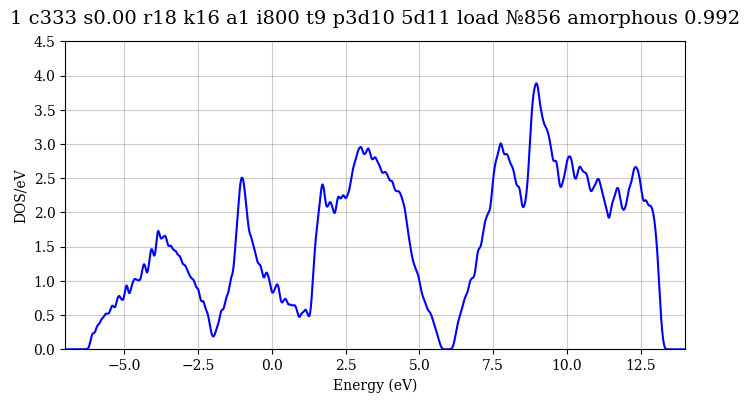

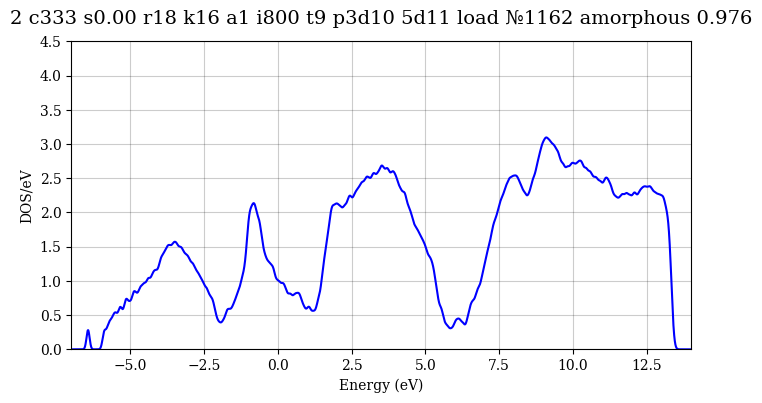

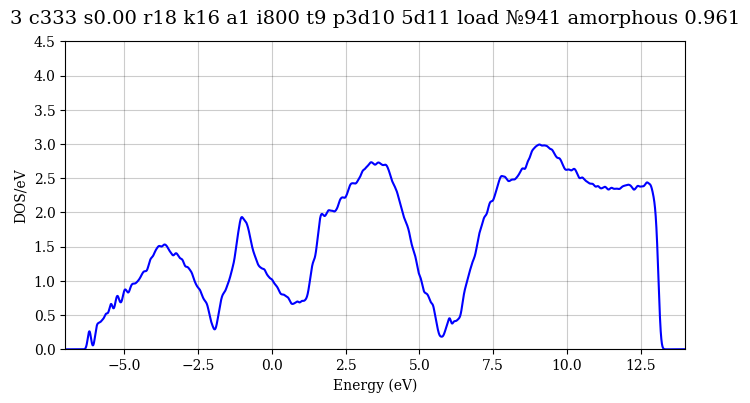

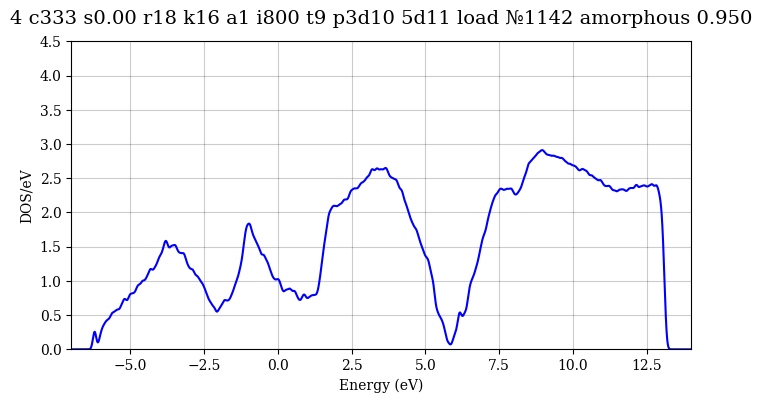

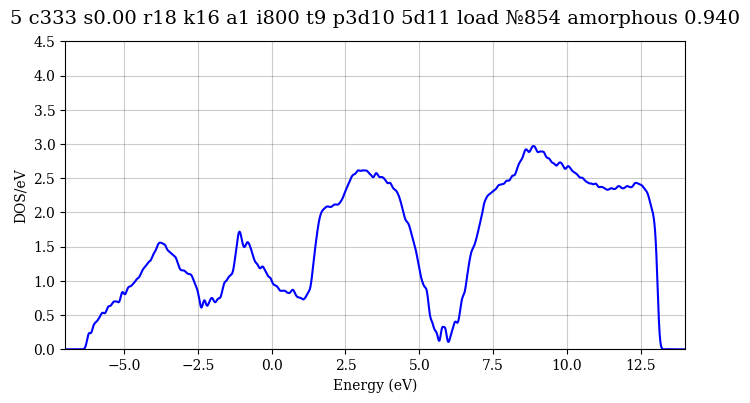

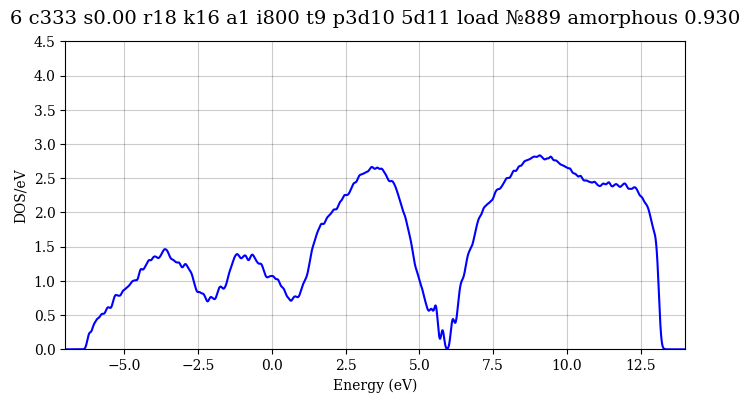

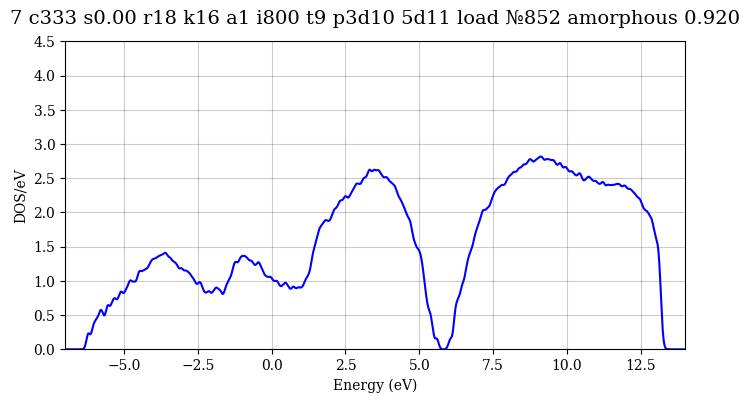

In [218]:
for folder_name in sorted_folders:

    # folder_name = sorted_folders[0]
    filename = folder_name + '/gs_eigen.data'
    
    n_bins = 2000
    bins_vals = np.linspace(-7, 14, n_bins)
    hist_sum = np.zeros(n_bins-1)
    
    
    
    for k_val in range(125):
    
        energies = read_energies_for_k(filename, k_val+1)
        hist, _ = np.histogram(energies, bins=bins_vals)
        hist_sum = hist_sum + hist
    
        # # if (k_val+1)%25==0:
        # if (k_val+1)==125:
    
        #     plt.figure(figsize=(8, 4))
        #     plt.title(' '.join(re.split('[/_]', folder_name)), fontsize=14, y=1.03)
        #     plt.bar(bins_vals[:-1], hist_sum/(k_val+1)/27, width=np.diff(bins_vals), align='edge', color='b')
        #     plt.xlabel("1-particle energy (eV)")
        #     plt.ylabel("Counts")
        #     plt.ylim(0, 15*200/n_bins/27)
        #     plt.xlim(-7, 13.5)
        #     plt.show()
    
    hist_sum_cell = hist_sum/125/27
    print("Number of states :", np.sum(hist_sum_cell))
    
    bins_centers = (bins_vals[:-1]+bins_vals[1:])/2
    
    
    
    
    num_points = 50000
    energy_vals = np.linspace(-7, 14, num_points)
    del_width = (bins_centers[1]-bins_centers[0])
    
    delta_sum = np.zeros(num_points)
    
    for bin_center, hist_val in zip(bins_centers, hist_sum_cell):
        delta = delta_gauss(energy_vals, del_width/0.2, bin_center)
    
        delta_sum = delta_sum + hist_val*delta
    
    plt.figure(figsize=(8, 4))
    plt.title(' '.join(re.split('[/_]', folder_name)), fontsize=14, y=1.03)
    plt.plot(energy_vals, delta_sum, color='b')
    plt.ylim(0, 4.5)
    plt.xlim(-7, 14)
    plt.grid(color='black', alpha=0.2)
    plt.xlabel("Energy (eV)")
    plt.ylabel("DOS/eV")

    plt.savefig("dos/" + folder_name + ".png", dpi=200)

    if folder_name == sorted_folders[0]:
        delta_sum1 = delta_sum

    if folder_name == sorted_folders[6]:
        delta_sum2 = delta_sum

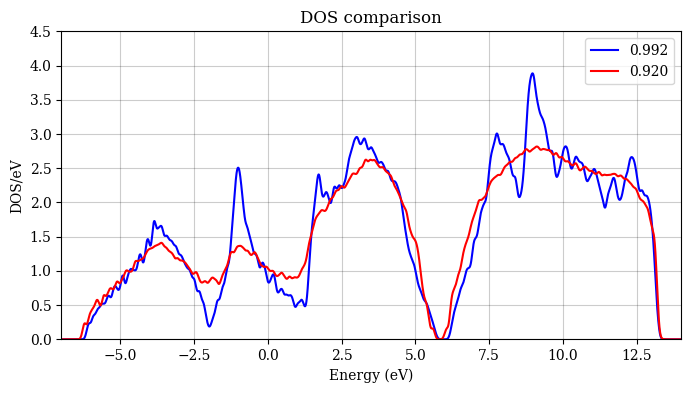

In [220]:
plt.figure(figsize=(8, 4))
plt.title("DOS comparison")
plt.plot(energy_vals, delta_sum1, color='b', label="0.992")
plt.plot(energy_vals, delta_sum2, color='r', label="0.920")
plt.ylim(0, 4.5)
plt.xlim(-7, 14)
plt.grid(color='black', alpha=0.2)
plt.xlabel("Energy (eV)")
plt.ylabel("DOS/eV")
plt.legend()

plt.savefig("dos/" + "DOS_comparison" + ".png", dpi=200)

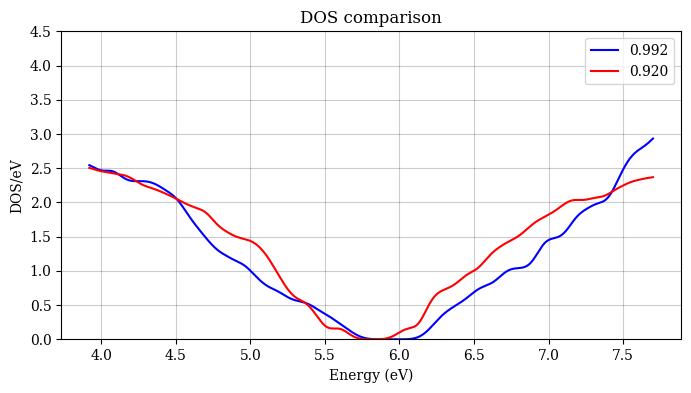

In [228]:
plt.figure(figsize=(8, 4))
plt.title("DOS comparison")
plt.plot(energy_vals[26000:35000], delta_sum1[26000:35000], color='b', label="0.992")
plt.plot(energy_vals[26000:35000], delta_sum2[26000:35000], color='r', label="0.920")
plt.ylim(0, 4.5)
# plt.xlim(-7, 14)
plt.grid(color='black', alpha=0.2)
plt.xlabel("Energy (eV)")
plt.ylabel("DOS/eV")
plt.legend()

plt.savefig("dos/" + "DOS_comparison_gap" + ".png", dpi=200)